In [192]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import norm

aqi = pd.read_csv("air_quality.csv")
gps = pd.read_csv("gps.csv")
pth = pd.read_csv("pth.csv")
radiation = pd.read_csv("radiation.csv")
spectrum = pd.read_csv("spectrum.csv")

In [193]:
gps.head()

,timestamp,latitude,longitude,accuracy
0,1.776898e+09,37.875980,-122.259010,19.999999
1,1.776898e+09,37.875980,-122.259010,19.999999
2,1.776898e+09,37.875980,-122.259010,142.195014
3,1.776898e+09,37.875981,-122.259011,830.828863
4,1.776898e+09,37.875980,-122.259012,19.994216


In [194]:
gps['readableTime'] = pd.to_datetime(gps['timestamp'], unit='s')
aqi['readableTime'] = pd.to_datetime(aqi['timestamp'], unit='s')
pth['readableTime'] = pd.to_datetime(pth['timestamp'], unit='s')
spectrum['readableTime'] = pd.to_datetime(spectrum['timestamp'], unit='s')
radiation['readableTime'] = pd.to_datetime(radiation['timestamp'], unit='s')
# gps

In [195]:
elapsedGPS = gps['readableTime'].max() - gps['readableTime'].min()
print(f"Elapsed GPS time: {elapsedGPS}")

elapsedAQI = aqi['readableTime'].max() - aqi['readableTime'].min()
print(f"Elapsed AQI time: {elapsedAQI}")

elapsedPTH = pth['readableTime'].max() - pth['readableTime'].min()
print(f"Elapsed PTH time: {elapsedPTH}")

elapsedRad = radiation['readableTime'].max() - radiation['readableTime'].min()
print(f"Elapsed radiation time: {elapsedRad}")

gps = gps.sort_values('readableTime')

Elapsed GPS time: 0 days 00:16:16.264069558
Elapsed AQI time: 0 days 00:01:37.824878931
Elapsed PTH time: 0 days 00:21:27.213502884
Elapsed radiation time: 0 days 00:20:56.085893631


## Radiation

In [196]:
cutRad = radiation['readableTime'].min() + pd.Timedelta(minutes = 4, seconds = 40)
newRad = radiation[radiation['readableTime'] >= cutRad].copy()

newRad = newRad.sort_values('readableTime')

radPos = pd.merge_asof(gps, newRad, on='readableTime', direction='nearest')
display(radPos)

,timestamp_x,latitude,longitude,accuracy,readableTime,timestamp_y,cps,cps_err,usv_hr
0,1.776898e+09,37.875980,-122.259010,19.999999,2026-04-22 22:54:07.203642368,1.776898e+09,6.0,1.732051,0.075204
1,1.776898e+09,37.875980,-122.259010,19.999999,2026-04-22 22:54:07.212212086,1.776898e+09,6.0,1.732051,0.075204
2,1.776898e+09,37.875980,-122.259010,142.195014,2026-04-22 22:54:07.221303701,1.776898e+09,6.0,1.732051,0.075204
3,1.776898e+09,37.875981,-122.259011,830.828863,2026-04-22 22:54:07.247111082,1.776898e+09,6.0,1.732051,0.075204
4,1.776898e+09,37.875980,-122.259012,19.994216,2026-04-22 22:54:07.767276764,1.776898e+09,6.0,1.732051,0.075204
...,...,...,...,...,...,...,...,...,...
420,1.776899e+09,37.875950,-122.258818,19.938783,2026-04-22 23:10:11.603847504,1.776899e+09,6.5,1.802776,0.081471
421,1.776899e+09,37.875980,-122.259013,19.966232,2026-04-22 23:10:17.518446445,1.776899e+09,6.5,1.802776,0.081471
422,1.776899e+09,37.875980,-122.259013,24.339673,2026-04-22 23:10:17.752714634,1.776899e+09,6.5,1.802776,0.081471
423,1.776899e+09,37.875980,-122.259013,24.370141,2026-04-22 23:10:17.761883974,1.776899e+09,6.5,1.802776,0.081471


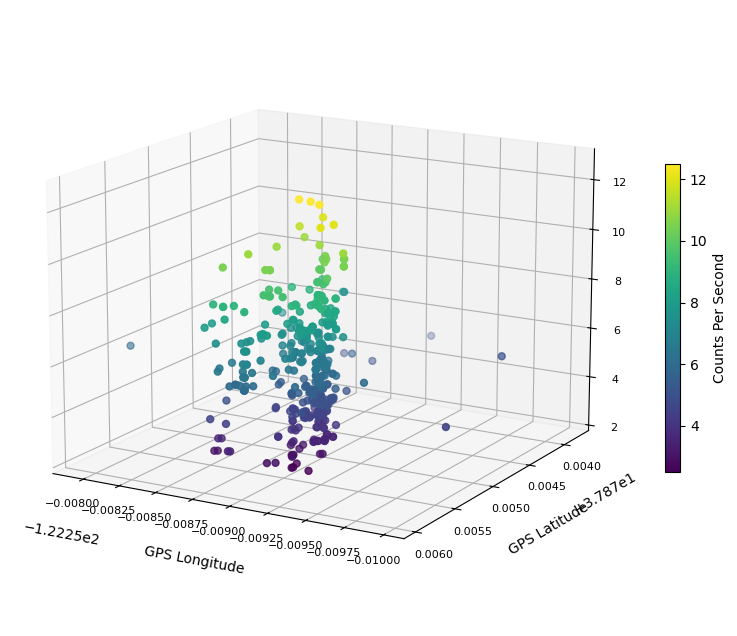

In [197]:
fig = plt.figure(figsize = (10, 8))
ax = fig.add_subplot(111, projection = "3d")

scatter = ax.scatter(radPos["longitude"], radPos["latitude"], radPos["cps"], c = radPos["cps"], cmap = "viridis", s = 25)
colorbar = plt.colorbar(scatter, label = "Counts Per Second", shrink = 0.5)
ax.tick_params(axis = "both", which = "major", length = 2, width = 0.5, labelsize = 8)
ax.set_xlabel("GPS Longitude", labelpad = 10)
ax.set_ylabel("GPS Latitude", labelpad = 10)
ax.view_init(elev = 15, azim = 120)
plt.show()

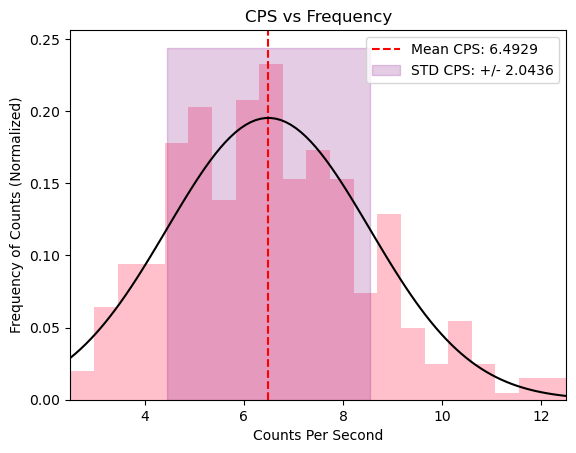

In [198]:
fig, ax = plt.subplots()

radMean, radStd = norm.fit(radPos["cps"])
x = np.linspace(radPos["cps"].min(), radPos["cps"].max(), 100)
pdf = norm.pdf(x, radMean, radStd)

plt.hist(radPos["cps"], bins = 21, density = True, color = "pink")
plt.axvline(radMean, color = "r", linestyle = "--", label = "Mean CPS: " + str(round(radMean, 4)))

x_fill = np.linspace(radMean - radStd, radMean + radStd, 100)
plt.fill_between(x_fill, 0, ax.get_ylim()[1], color = "purple", alpha = 0.2, label = "STD CPS: +/- " + str(round(radStd, 4)))

plt.plot(x, pdf, color = "k")

plt.title("CPS vs Frequency")
plt.xlabel("Counts Per Second")
plt.xlim(radPos["cps"].min(), radPos["cps"].max())
plt.ylabel("Frequency of Counts (Normalized)")
plt.legend()
plt.show()

## Temperature & Altitude

In [199]:
cutoffPTH = pth['readableTime'].min() + pd.Timedelta(minutes = 5, seconds = 10)
pthNew = pth[pth['readableTime'] >= cutoffPTH].copy()
print(f"New PTH elapsed time: {pthNew['readableTime'].max() - pthNew['readableTime'].min()}")

New PTH elapsed time: 0 days 00:16:16.682926416


In [200]:
gps = gps.sort_values('readableTime')
pthNew = pthNew.sort_values('readableTime')

# 2. Match PTH data to the GPS timestamps
# This will result in exactly 425 rows
GPSPTH = pd.merge_asof(gps, pthNew, 
                         on='readableTime', 
                         direction='nearest')

GPSPTH

,timestamp_x,latitude,longitude,accuracy,readableTime,timestamp_y,temp_mean,temp_err,hum_mean,hum_err,press_mean,press_err,alt_mean,alt_err,voc_mean,voc_err
0,1.776898e+09,37.875980,-122.259010,19.999999,2026-04-22 22:54:07.203642368,1.776898e+09,28.714473,0.000293,39.155144,0.003004,1010.779094,0.001361,20.592318,0.011357,174599.0,90.0
1,1.776898e+09,37.875980,-122.259010,19.999999,2026-04-22 22:54:07.212212086,1.776898e+09,28.714473,0.000293,39.155144,0.003004,1010.779094,0.001361,20.592318,0.011357,174599.0,90.0
2,1.776898e+09,37.875980,-122.259010,142.195014,2026-04-22 22:54:07.221303701,1.776898e+09,28.714473,0.000293,39.155144,0.003004,1010.779094,0.001361,20.592318,0.011357,174599.0,90.0
3,1.776898e+09,37.875981,-122.259011,830.828863,2026-04-22 22:54:07.247111082,1.776898e+09,28.714473,0.000293,39.155144,0.003004,1010.779094,0.001361,20.592318,0.011357,174599.0,90.0
4,1.776898e+09,37.875980,-122.259012,19.994216,2026-04-22 22:54:07.767276764,1.776898e+09,28.714473,0.000293,39.155144,0.003004,1010.779094,0.001361,20.592318,0.011357,174599.0,90.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420,1.776899e+09,37.875950,-122.258818,19.938783,2026-04-22 23:10:11.603847504,1.776899e+09,26.724043,0.000488,40.191410,0.059584,1010.594439,0.029352,22.132862,0.244893,148227.5,976.5
421,1.776899e+09,37.875980,-122.259013,19.966232,2026-04-22 23:10:17.518446445,1.776899e+09,26.716914,0.000195,40.946773,0.038965,1010.751354,0.002088,20.823736,0.017423,159574.5,226.5
422,1.776899e+09,37.875980,-122.259013,24.339673,2026-04-22 23:10:17.752714634,1.776899e+09,26.716914,0.000195,40.946773,0.038965,1010.751354,0.002088,20.823736,0.017423,159574.5,226.5
423,1.776899e+09,37.875980,-122.259013,24.370141,2026-04-22 23:10:17.761883974,1.776899e+09,26.716914,0.000195,40.946773,0.038965,1010.751354,0.002088,20.823736,0.017423,159574.5,226.5


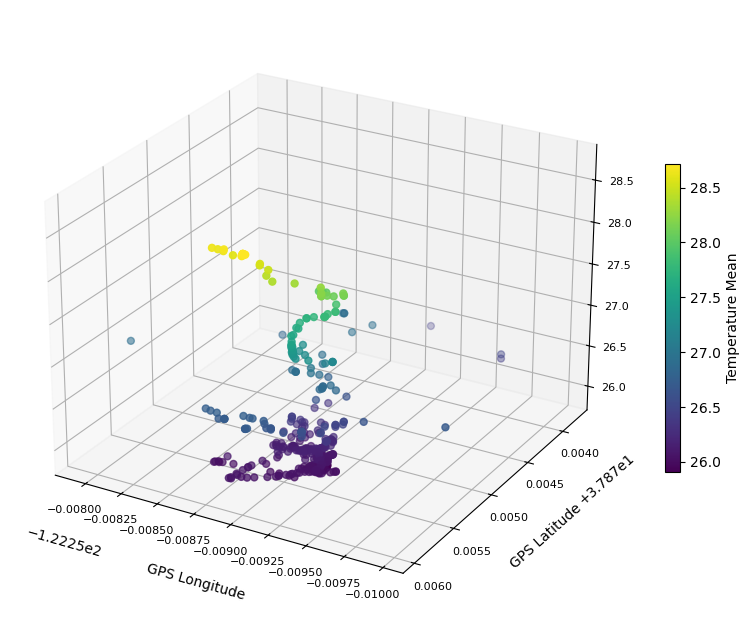

In [201]:
fig = plt.figure(figsize = (10,8))
ax = fig.add_subplot(111, projection = '3d')

scatter = ax.scatter(GPSPTH['longitude'], GPSPTH['latitude'], GPSPTH['temp_mean'], c = GPSPTH['temp_mean'], cmap = 'viridis', s = 25)
colorbar = plt.colorbar(scatter, label = 'Temperature Mean', shrink = 0.5)

ax.tick_params(axis = 'both', which = 'major', length = 2, width = 0.5, labelsize = 8)
ax.set_xlabel('GPS Longitude', labelpad = 10)
ax.set_ylabel('GPS Latitude', labelpad = 10)
#ax.set_zlabel('Temperature Mean', labelpad = 10)

ax.view_init(elev = 25, azim = 120)

#plt.title('Temperature Mean vs. Longitude and Latitude', fontsize = 20)
#plt.grid(alpha = 0.5)
plt.show()

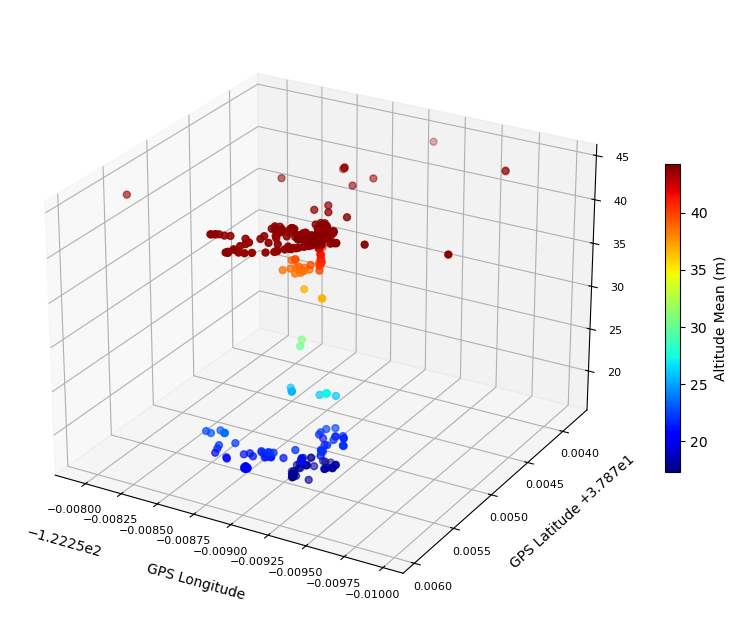

In [202]:
fig = plt.figure(figsize = (10,8))
ax = fig.add_subplot(111, projection = '3d')

scatter = ax.scatter(GPSPTH['longitude'], GPSPTH['latitude'], GPSPTH['alt_mean'], c = GPSPTH['alt_mean'], cmap = 'jet', s = 25)
colorbar = plt.colorbar(scatter, label = 'Altitude Mean (m)', shrink = 0.5)

ax.tick_params(axis = 'both', which = 'major', length = 2, width = 0.5, labelsize = 8)
ax.set_xlabel('GPS Longitude', labelpad = 10)
ax.set_ylabel('GPS Latitude', labelpad = 10)
#ax.set_zlabel('Temperature Mean', labelpad = 10)

ax.view_init(elev = 25, azim = 120)

#plt.title('Temperature Mean vs. Longitude and Latitude', fontsize = 20)
#plt.grid(alpha = 0.5)
plt.show()

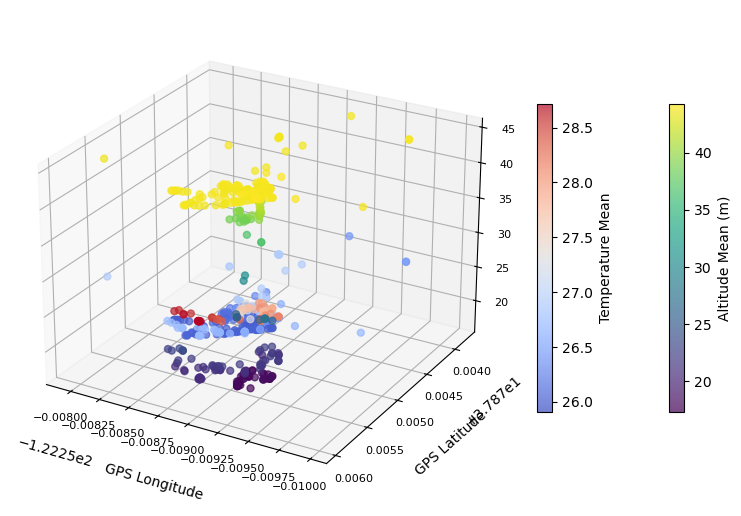

In [203]:
fig = plt.figure(figsize = (10,8))
ax = fig.add_subplot(111, projection = '3d')

scatter = ax.scatter(GPSPTH['longitude'], GPSPTH['latitude'], GPSPTH['alt_mean'], c = GPSPTH['alt_mean'], cmap = 'viridis', s = 25, alpha = 0.7)
colorbar = plt.colorbar(scatter, label = 'Altitude Mean (m)', shrink = 0.5)

scatter = ax.scatter(GPSPTH['longitude'], GPSPTH['latitude'], GPSPTH['temp_mean'], c = GPSPTH['temp_mean'], cmap = 'coolwarm', s = 25, alpha = 0.7)
colorbar = plt.colorbar(scatter, label = 'Temperature Mean', shrink = 0.5)

ax.tick_params(axis = 'both', which = 'major', length = 2, width = 0.5, labelsize = 8)
ax.set_xlabel('GPS Longitude', labelpad = 10)
ax.set_ylabel('GPS Latitude', labelpad = 10)
#ax.set_zlabel('Temperature Mean', labelpad = 10)

ax.view_init(elev = 25, azim = 120)

#plt.title('Temperature Mean vs. Longitude and Latitude', fontsize = 20)
#plt.grid(alpha = 0.5)
plt.show()

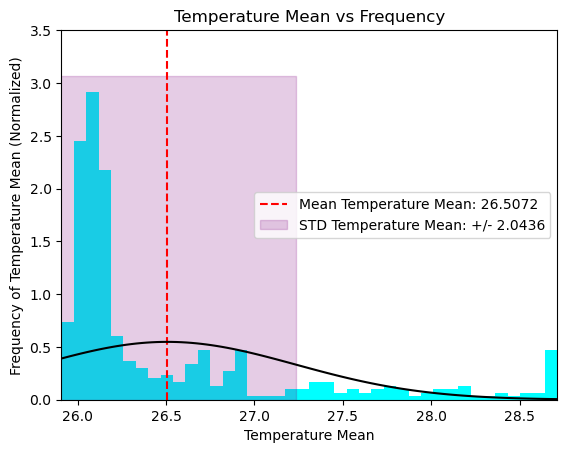

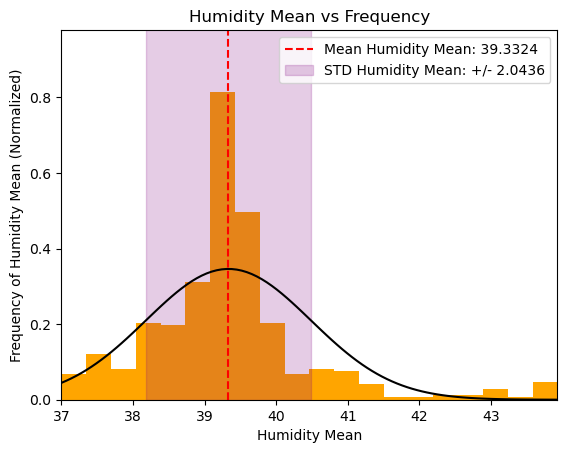

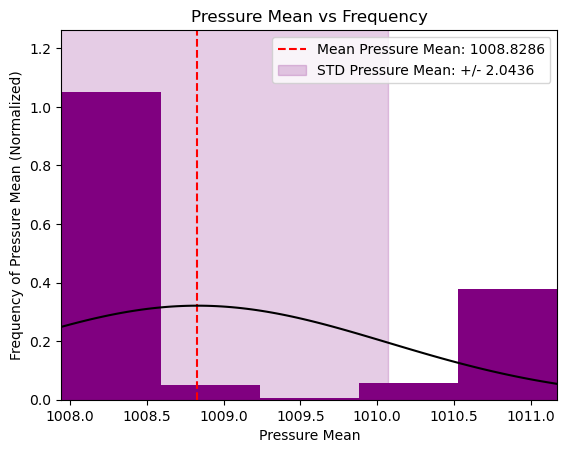

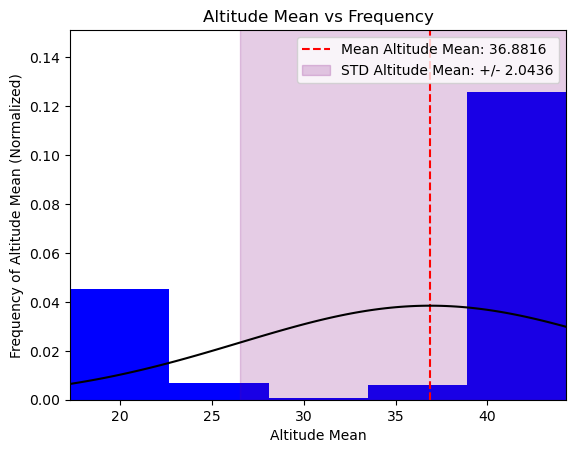

In [204]:
#temp_mean, hum_mean, press_mean, alt_mean
fig, ax = plt.subplots()

dataList = [GPSPTH["temp_mean"], GPSPTH["hum_mean"], GPSPTH["press_mean"], GPSPTH["alt_mean"]]
binsList = [40, 20, 5, 5]
colors = ["cyan", "orange", "purple", "blue"]
labelList = ["Temperature Mean", "Humidity Mean", "Pressure Mean", "Altitude Mean"]
for i in range(4):
    mean, std = norm.fit(dataList[i])
    x = np.linspace(dataList[i].min(), dataList[i].max(), 100)
    pdf = norm.pdf(x, mean, std)

    n, bins, patches = plt.hist(dataList[i], bins = binsList[i], density = True, color = colors[i])
    plt.axvline(mean, color = "r", linestyle = "--", label = "Mean " + labelList[i] + ": " + str(round(mean, 4)))

    x_fill = np.linspace(mean - std, mean + std, 100)
    plt.fill_between(x_fill, 0, ax.get_ylim()[1], color = "purple", alpha = 0.2, label = "STD " + labelList[i] + ": +/- " + str(round(radStd, 4)))
    plt.plot(x, pdf, color = "k")

    plt.title(labelList[i] + " vs Frequency")
    plt.xlabel(labelList[i])
    plt.xlim(dataList[i].min(), dataList[i].max())
    plt.ylabel("Frequency of " + labelList[i] + " (Normalized)")
    plt.ylim(0, n.max() * 1.2)
    plt.legend()
    plt.show()

## PM2.5

In [205]:
gps = pd.read_csv('gps.csv')
aqi = pd.read_csv('air_quality.csv')

gps['readableTime'] = pd.to_datetime(gps['timestamp'], unit='s')
aqi['readableTime'] = pd.to_datetime(aqi['timestamp'], unit='s')

elapsedGPS = gps['readableTime'].max() - gps['readableTime'].min()
elapsedAQI = aqi['readableTime'].max() - aqi['readableTime'].min()

print(f"Elapsed GPS time: {elapsedGPS}")
print(f"Elapsed AQI time: {elapsedAQI}")

Elapsed GPS time: 0 days 00:16:16.264069558
Elapsed AQI time: 0 days 00:01:37.824878931


In [206]:
gps = gps.sort_values('readableTime')
aqi = aqi.sort_values('readableTime')
GPSAQI = pd.merge_asof(gps, aqi[['readableTime', 'pm25_mean']], 
                       on='readableTime', 
                       direction='nearest')
display(GPSAQI)

,timestamp,latitude,longitude,accuracy,readableTime,pm25_mean
0,1.776898e+09,37.875980,-122.259010,19.999999,2026-04-22 22:54:07.203642368,0.0
1,1.776898e+09,37.875980,-122.259010,19.999999,2026-04-22 22:54:07.212212086,0.0
2,1.776898e+09,37.875980,-122.259010,142.195014,2026-04-22 22:54:07.221303701,0.0
3,1.776898e+09,37.875981,-122.259011,830.828863,2026-04-22 22:54:07.247111082,0.0
4,1.776898e+09,37.875980,-122.259012,19.994216,2026-04-22 22:54:07.767276764,0.0
...,...,...,...,...,...,...
420,1.776899e+09,37.875950,-122.258818,19.938783,2026-04-22 23:10:11.603847504,0.0
421,1.776899e+09,37.875980,-122.259013,19.966232,2026-04-22 23:10:17.518446445,0.0
422,1.776899e+09,37.875980,-122.259013,24.339673,2026-04-22 23:10:17.752714634,0.0
423,1.776899e+09,37.875980,-122.259013,24.370141,2026-04-22 23:10:17.761883974,0.0


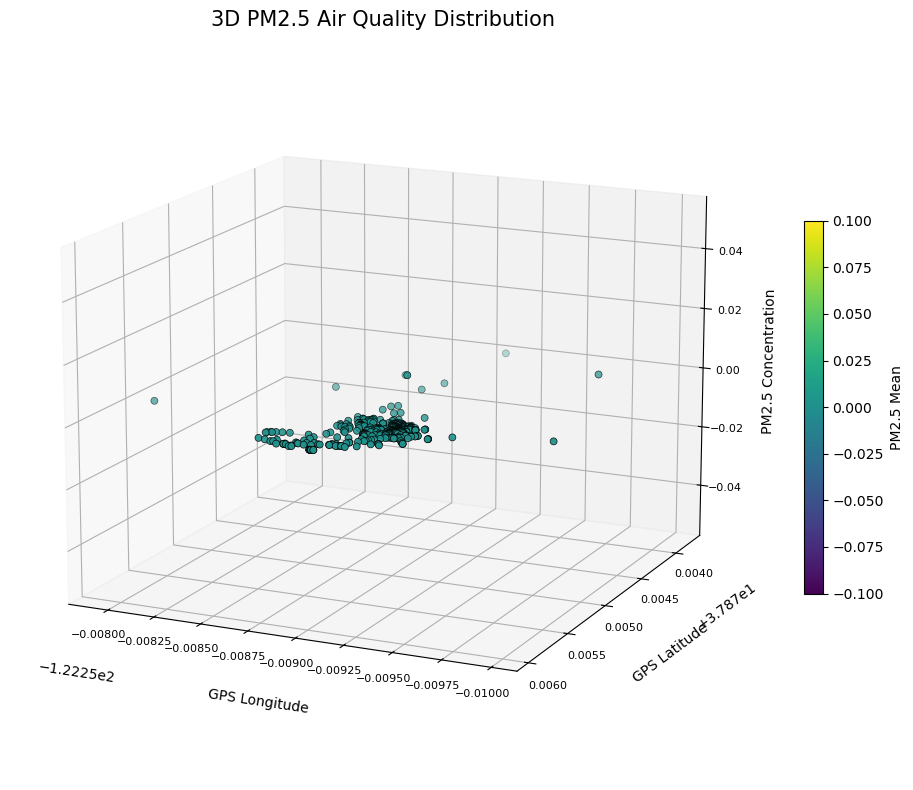

In [207]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    GPSAQI['longitude'], 
    GPSAQI['latitude'], 
    GPSAQI['pm25_mean'], 
    c=GPSAQI['pm25_mean'], 
    cmap='viridis', 
    s=(GPSAQI['pm25_mean'] * 300) + 25, 
    edgecolors='black',
    linewidth=0.5
)

ax.set_xlabel('GPS Longitude', labelpad=15)
ax.set_ylabel('GPS Latitude', labelpad=15)
ax.set_zlabel('PM2.5 Concentration', labelpad=10)
plt.title('3D PM2.5 Air Quality Distribution', fontsize=15)

colorbar = plt.colorbar(scatter, label='PM2.5 Mean', shrink=0.5)
ax.view_init(elev=15, azim=115)
ax.tick_params(axis='both', which='major', labelsize=8)
plt.tight_layout()
plt.show()

C:\Users\smile\anaconda3\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2065: RuntimeWarning: invalid value encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
C:\Users\smile\AppData\Local\Temp\ipykernel_24916\309332109.py:17: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.xlim(GPSAQI["pm25_mean"].min(), GPSAQI["pm25_mean"].max())


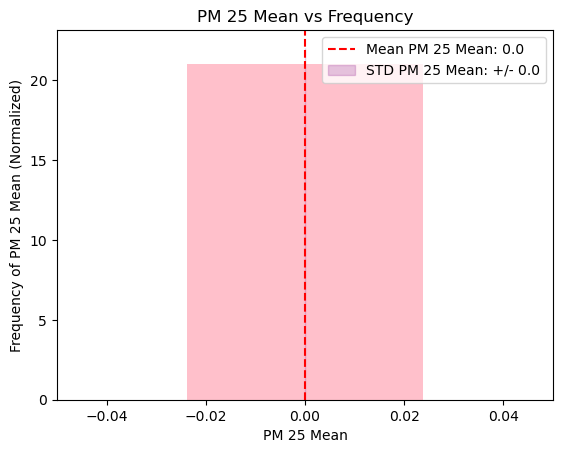

In [210]:
fig, ax = plt.subplots()

radMean, radStd = norm.fit(GPSAQI["pm25_mean"])
x = np.linspace(GPSAQI["pm25_mean"].min(), GPSAQI["pm25_mean"].max(), 100)
pdf = norm.pdf(x, radMean, radStd)

plt.hist(GPSAQI["pm25_mean"], bins = 21, density = True, color = "pink")
plt.axvline(radMean, color = "r", linestyle = "--", label = "Mean PM 25 Mean: " + str(round(radMean, 4)))

x_fill = np.linspace(radMean - radStd, radMean + radStd, 100)
plt.fill_between(x_fill, 0, ax.get_ylim()[1], color = "purple", alpha = 0.2, label = "STD PM 25 Mean: +/- " + str(round(radStd, 4)))

plt.plot(x, pdf, color = "k")

plt.title("PM 25 Mean vs Frequency")
plt.xlabel("PM 25 Mean")
plt.xlim(GPSAQI["pm25_mean"].min(), GPSAQI["pm25_mean"].max())
plt.ylabel("Frequency of PM 25 Mean (Normalized)")
plt.legend()
plt.show()

So every data point is zero, so histogram no work.